In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.wcs import WCS
import numpy as np
%matplotlib widget

In [2]:
# 读取LAMOST数据
lamost_df = pd.read_csv('LAMOST_DR11_RA14_22_DEC25_32_OBA.csv')

# 读取GAIA数据
gaia_df = pd.read_csv('../GAIA/GAIA_DR3_RA14_22_DEC25_32.csv')

# 读取FITS文件并获取WCS
fits_file = "../HI4PI HVC/HI4PI_RA14_22_DEC25_32_HVC_moment_1.fits"
hdul = fits.open(fits_file)
data = hdul[0].data
wcs = WCS(hdul[0].header)
hdul.close()

/tmp/ipykernel_268201/3459719658.py:14: UserWarning: You passed both c and facecolor/facecolors for the markers. c has precedence over facecolor/facecolors. This behavior may change in the future.
  ax.scatter(pixel_coords_lamost[:, 0], pixel_coords_lamost[:, 1], marker='o', facecolors='none',


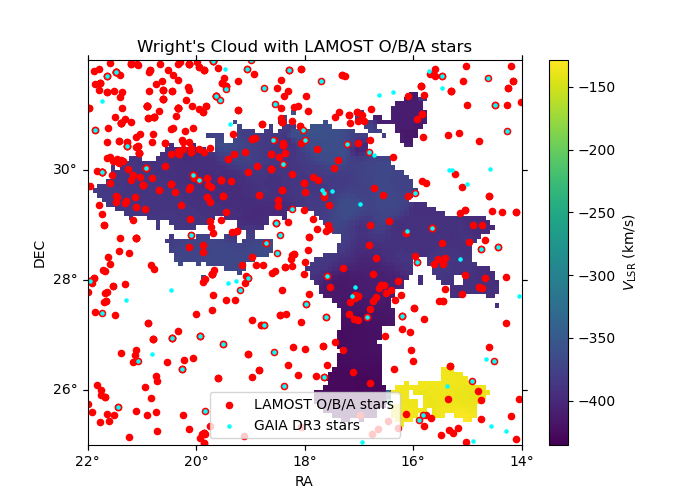

In [3]:
# 创建图形，使用FITS的WCS
fig = plt.figure(figsize=(7, 5))
ax = plt.subplot(projection=wcs)

# 用imshow显示FITS数据
im = ax.imshow(data, origin='lower', cmap='viridis', aspect='auto')
plt.colorbar(im, ax=ax, label=r'$V_{\mathrm{LSR}}\ (\mathrm{km/s})$')

# 将RA,DEC转换为像素坐标
pixel_coords_lamost = wcs.all_world2pix(np.array([lamost_df['ra'], lamost_df['dec']]).T, 0)
pixel_coords_gaia = wcs.all_world2pix(np.array([gaia_df['ra'], gaia_df['dec']]).T, 0)

# 叠加LAMOST源（红色空心点）和GAIA源（青色十字）
ax.scatter(pixel_coords_lamost[:, 0], pixel_coords_lamost[:, 1], marker='o', facecolors='none',
          s=20, c='red', label='LAMOST O/B/A stars')

ax.scatter(pixel_coords_gaia[:, 0], pixel_coords_gaia[:, 1], marker='o',
          s=5, c='cyan', label='GAIA DR3 stars')

# 设置坐标轴标签
ax.set_xlabel('RA')
ax.set_ylabel('DEC')
ax.set_title("Wright's Cloud with LAMOST O/B/A stars")

# 设置RA轴以度为单位显示
lon = ax.coords[0]
lon.set_major_formatter('d.ddd')  # 使用度格式
lon.set_format_unit('deg')        # 设置单位为度

# 显示图例
ax.legend()

# 显示图形
plt.show()

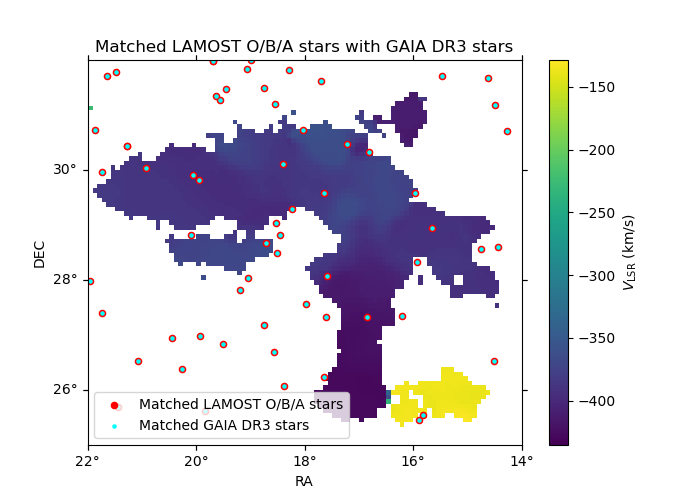

In [4]:
# 筛选LAMOST与GAIA重合的源
from astropy.coordinates import SkyCoord
from astropy import units as u

lamost_coords = SkyCoord(ra=lamost_df['ra'].astype(float).values*u.degree, dec=lamost_df['dec'].astype(float).values*u.degree, frame='icrs')
gaia_coords = SkyCoord(ra=gaia_df['ra'].astype(float).values*u.degree, dec=gaia_df['dec'].astype(float).values*u.degree, frame='icrs')
idx, d2d, _ = lamost_coords.match_to_catalog_sky(gaia_coords)
match_mask = d2d < 1*u.arcsec  # 设置匹配阈值为1弧秒
matched_lamost = lamost_df[match_mask]
matched_gaia = gaia_df.iloc[idx[match_mask]]

# 去除重复的源
matched_lamost = matched_lamost.drop_duplicates(subset=['uid']).copy()
matched_gaia = matched_gaia.drop_duplicates(subset=['source_id']).copy()

matched_pixel_coords_lamost = wcs.all_world2pix(np.array([matched_lamost['ra'], matched_lamost['dec']]).T, 0)
matched_pixel_coords_gaia = wcs.all_world2pix(np.array([matched_gaia['ra'], matched_gaia['dec']]).T, 0)

# 画图显示匹配的源
fig = plt.figure(figsize=(7, 5))
ax = plt.subplot(projection=wcs)
im = ax.imshow(data, origin='lower', cmap='viridis', aspect='auto')
plt.colorbar(im, ax=ax, label=r'$V_{\mathrm{LSR}}\ (\mathrm{km/s})$')
ax.scatter(matched_pixel_coords_lamost[:, 0], matched_pixel_coords_lamost[:, 1], marker='o',
          s=20, c='red', label='Matched LAMOST O/B/A stars')
ax.scatter(matched_pixel_coords_gaia[:, 0], matched_pixel_coords_gaia[:, 1], marker='o',
          s=5, c='cyan', label='Matched GAIA DR3 stars')
ax.set_xlabel('RA')
ax.set_ylabel('DEC')
ax.set_title('Matched LAMOST O/B/A stars with GAIA DR3 stars')
lon = ax.coords[0]
lon.set_major_formatter('d.ddd')
lon.set_format_unit('deg')
ax.legend()
plt.show()

In [5]:
# 在匹配的源中找和HVC重叠的源
# LAMOST和GAIA的匹配源中，计算出赤经、赤纬坐标，反过来计算出像素坐标，判断是否在HVC的范围内（该像素值是否小于-300）
hvc_mask_lamost = data[matched_pixel_coords_lamost[:, 1].astype(int), matched_pixel_coords_lamost[:, 0].astype(int)] < -300
hvc_mask_gaia = data[matched_pixel_coords_gaia[:, 1].astype(int), matched_pixel_coords_gaia[:, 0].astype(int)] < -300

# 筛选出在HVC范围内的源
matched_lamost_filtered = matched_lamost[hvc_mask_lamost].copy()
matched_gaia_filtered = matched_gaia[hvc_mask_gaia].copy()
len(matched_lamost_filtered), len(matched_gaia_filtered)

(12, 12)

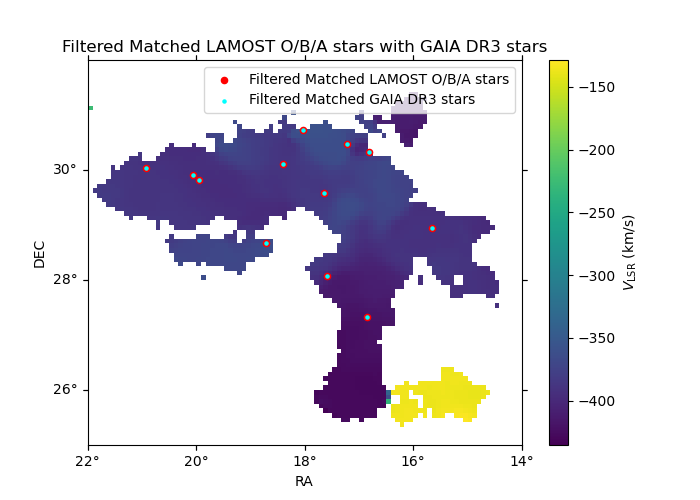

In [6]:
# 画图显示筛选后的匹配源
fig = plt.figure(figsize=(7, 5))
ax = plt.subplot(projection=wcs)
im = ax.imshow(data, origin='lower', cmap='viridis', aspect='auto')
plt.colorbar(im, ax=ax, label=r'$V_{\mathrm{LSR}}\ (\mathrm{km/s})$')
ax.scatter(matched_pixel_coords_lamost[hvc_mask_lamost, 0], matched_pixel_coords_lamost[hvc_mask_lamost, 1], marker='o',
          s=20, c='red', label='Filtered Matched LAMOST O/B/A stars')
ax.scatter(matched_pixel_coords_gaia[hvc_mask_gaia, 0], matched_pixel_coords_gaia[hvc_mask_gaia, 1], marker='o',
          s=5, c='cyan', label='Filtered Matched GAIA DR3 stars')
ax.set_xlabel('RA')
ax.set_ylabel('DEC')
ax.set_title('Filtered Matched LAMOST O/B/A stars with GAIA DR3 stars')
lon = ax.coords[0]
lon.set_major_formatter('d.ddd')
lon.set_format_unit('deg')
ax.legend()
plt.show()

In [7]:
# 将GAIA匹配源的parallax转化为距离

parallax_gaia = matched_gaia_filtered['parallax'].astype(float).values * u.mas

distance_gaia = parallax_gaia.to(u.kpc, equivalencies=u.parallax())

matched_gaia_filtered['distance_kpc'] = distance_gaia.value
print(matched_gaia_filtered[['source_id', 'ra', 'dec', 'parallax', 'distance_kpc']])
print(matched_lamost_filtered[['uid', 'ra', 'dec']])

             source_id         ra        dec  parallax  distance_kpc
72  311322216279519872  15.653779  28.945526  0.434040      2.303936
64  313020210125459712  16.810562  30.320541  0.268835      3.719754
38  307933972414398720  16.847060  27.324845  0.467100      2.140867
16  313037321275223168  17.216264  30.471830  1.691561      0.591170
70  308076118651980032  17.576495  28.069535  0.318011      3.144547
57  309911340997977600  17.646523  29.582602  0.295158      3.388012
85  310130002077314688  18.019529  30.723692  1.099312      0.909660
80  309859354713675648  18.394489  30.107509  0.227722      4.391319
92  308863575136063360  18.707162  28.678773  0.358018      2.793157
9   309416247232287744  19.939234  29.813409  0.655689      1.525114
3   309418862867813632  20.046939  29.911439  0.396602      2.521418
2   309391787394140288  20.919559  30.042266  0.371639      2.690782
                 uid         ra        dec
77   G17227197810176  15.653813  28.945540
144  G17219886517